## Error Analysis – ResNet50 for Pneumonia Detection

### What was done?

1. **Model**  
   A pretrained ResNet50 was fine‑tuned on the Chest X‑Ray Pneumonia dataset. The final fully connected layers were replaced with a custom head (Linear → ReLU → BatchNorm → Dropout → Linear → ReLU → Dropout → Linear) to classify images as **NORMAL** or **PNEUMONIA**.

2. **Evaluation**  
   The model was evaluated on the **test set** (624 images: 234 NORMAL, 390 PNEUMONIA).  
   Predictions were generated, and standard classification metrics were computed.

3. **Error analysis steps**  
   - **Confusion matrix** – to visualise correct vs. incorrect predictions.  
   - **ROC curve & AUC** – to assess discriminative ability across thresholds.  
   - **Confidence distribution** – to examine how predicted probabilities differ between true classes.  
   - **Visual inspection** – to review example false positives (NORMAL predicted as PNEUMONIA) and false negatives (PNEUMONIA missed), sorted by confidence.

4. **Clinical focus**  
   Special attention was given to **false negatives**, as these represent missed pneumonia cases – the most critical error type in a medical screening context.

In [1]:
import kagglehub
import os
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
base_path = os.path.join(path, "chest_xray")

def load_data(data_dir):
    paths, labels = [], []
    for label_name in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(data_dir, label_name)
        label = 0 if label_name == "NORMAL" else 1
        for img in os.listdir(folder):
            if img.startswith("."):
                continue
            paths.append(os.path.join(folder, img))
            labels.append(label)
    return np.array(paths), np.array(labels)

test_paths, test_labels = load_data(os.path.join(base_path, "test"))

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class ChestDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx]).long()

test_loader = DataLoader(
    ChestDataset(test_paths, test_labels, val_transform),
    batch_size=32,
    shuffle=False
)

print(f"Test set: {len(test_paths)} images")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Test set: 624 images


In [2]:
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_resnet50():
    model = models.resnet50(weights=None)
    for p in model.layer1.parameters():
        p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(2048, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.5),
        nn.Linear(512, 128),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 2)
    )
    return model

r50 = get_resnet50()
r50.load_state_dict(torch.load("R50.pth", map_location=device))
r50.to(device)
r50.eval()
print("Model loaded.")

Model loaded.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = r50(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

In [4]:
print("=" * 40)
print(f"  Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"  Precision : {precision_score(all_labels, all_preds):.4f}")
print(f"  Recall    : {recall_score(all_labels, all_preds):.4f}")
print(f"  F1 Score  : {f1_score(all_labels, all_preds):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(all_labels, all_probs):.4f}")
print("=" * 40)

  Accuracy  : 0.9247
  Precision : 0.9193
  Recall    : 0.9641
  F1 Score  : 0.9412
  AUC-ROC   : 0.9740


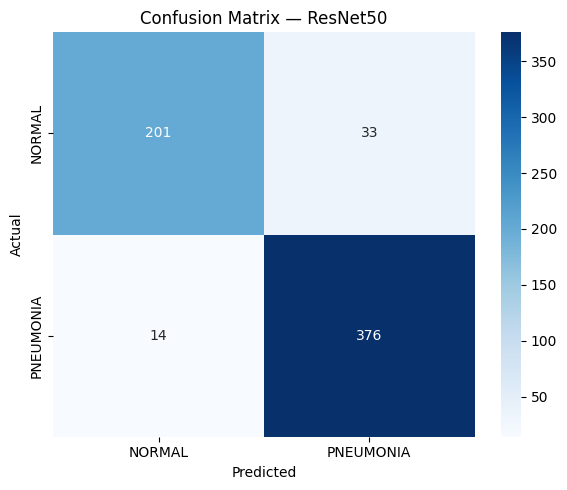

True Negatives  (correct NORMAL)    : 201
False Positives (NORMAL → PNEUMONIA): 33
False Negatives (PNEUMONIA → NORMAL): 14
True Positives  (correct PNEUMONIA) : 376


In [5]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix — ResNet50')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct NORMAL)    : {tn}")
print(f"False Positives (NORMAL → PNEUMONIA): {fp}")
print(f"False Negatives (PNEUMONIA → NORMAL): {fn}")
print(f"True Positives  (correct PNEUMONIA) : {tp}")

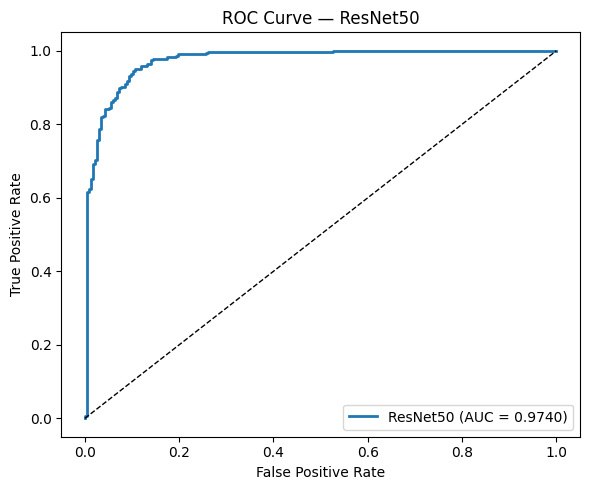

In [6]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ResNet50 (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ResNet50')
plt.legend()
plt.tight_layout()
plt.show()

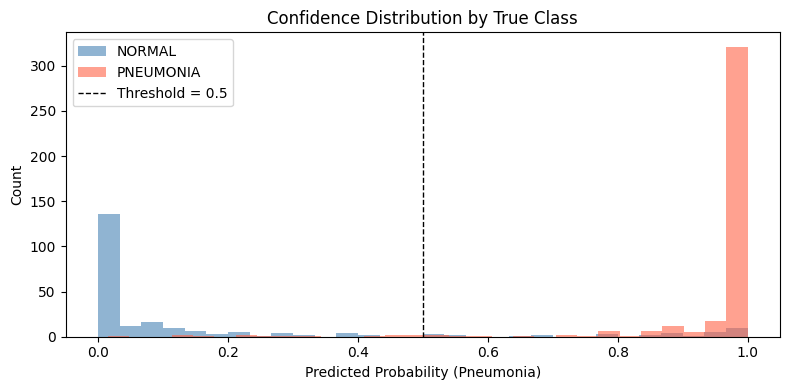

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(all_probs[all_labels == 0], bins=30, alpha=0.6, label='NORMAL', color='steelblue')
plt.hist(all_probs[all_labels == 1], bins=30, alpha=0.6, label='PNEUMONIA', color='tomato')
plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')
plt.xlabel('Predicted Probability (Pneumonia)')
plt.ylabel('Count')
plt.title('Confidence Distribution by True Class')
plt.legend()
plt.tight_layout()
plt.show()

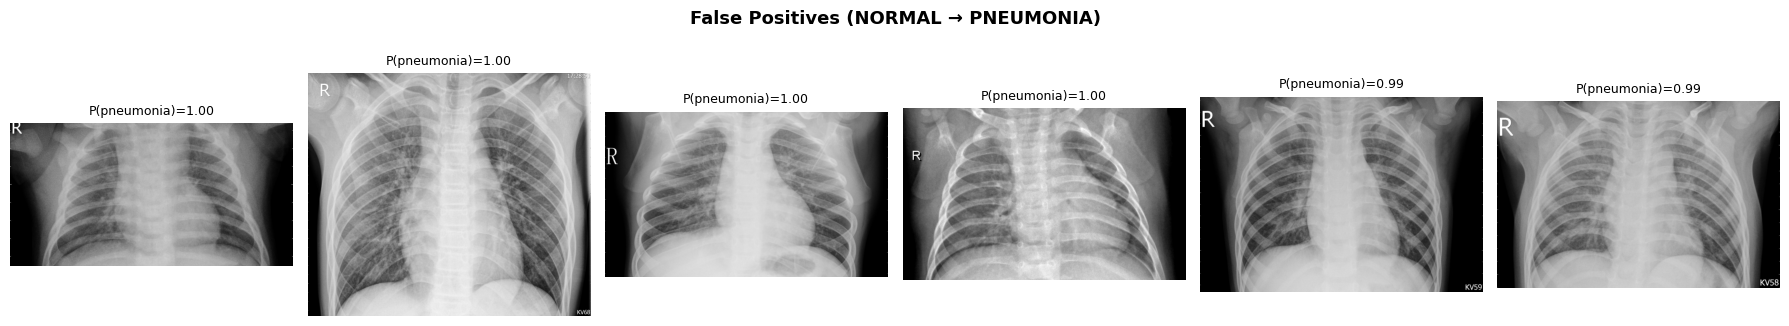

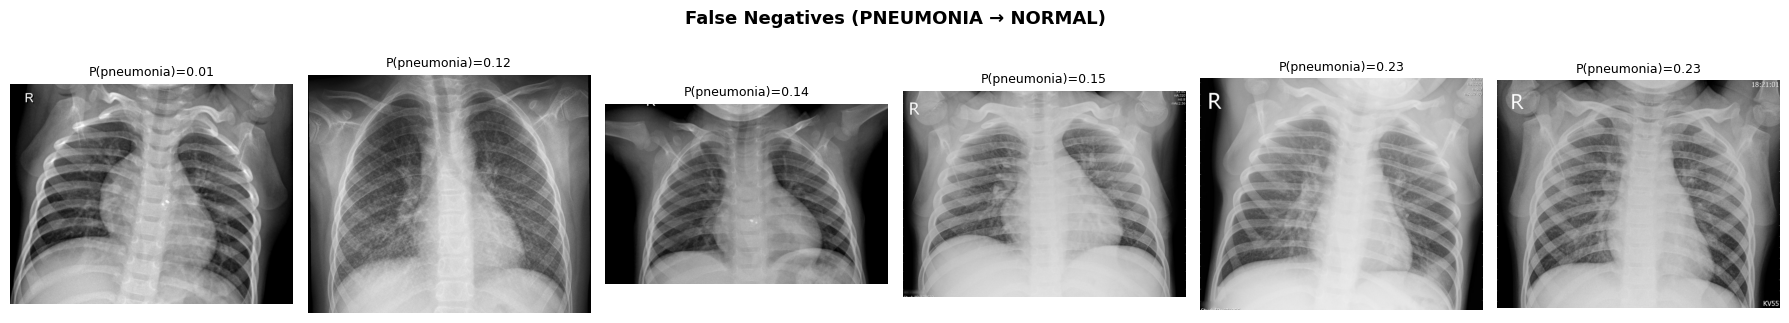

In [8]:
false_positives = np.where((all_preds == 1) & (all_labels == 0))[0]  # NORMAL predicted as PNEUMONIA
false_negatives = np.where((all_preds == 0) & (all_labels == 1))[0]  # PNEUMONIA predicted as NORMAL

def show_errors(indices, error_type, n=6):
    if len(indices) == 0:
        print(f"No {error_type} found.")
        return

    if error_type == "False Positives (NORMAL → PNEUMONIA)":
        # High pneumonia probability despite being normal
        conf = all_probs[indices]
        indices = indices[np.argsort(-conf)]
    else:
        # Low pneumonia probability despite being pneumonia
        conf = all_probs[indices]
        indices = indices[np.argsort(conf)]

    n = min(n, len(indices))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    fig.suptitle(error_type, fontsize=13, fontweight='bold')

    for i, idx in enumerate(indices[:n]):
        img = Image.open(test_paths[idx]).convert("RGB")
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        conf_val = all_probs[idx]
        axes[i].set_title(f'P(pneumonia)={conf_val:.2f}', fontsize=9)

    plt.tight_layout()
    plt.show()

show_errors(false_positives, "False Positives (NORMAL → PNEUMONIA)")
show_errors(false_negatives, "False Negatives (PNEUMONIA → NORMAL)")

In [9]:
total = len(all_labels)
print(f"Total test images   : {total}")
print(f"Correctly classified: {(all_preds == all_labels).sum()} ({(all_preds == all_labels).mean()*100:.1f}%)")
print(f"False Positives     : {len(false_positives)} — NORMAL cases flagged as PNEUMONIA")
print(f"False Negatives     : {len(false_negatives)} — PNEUMONIA cases missed")
print()
print("Clinical note: False Negatives are higher risk — missed pneumonia cases.")
print(f"Miss rate: {len(false_negatives) / (all_labels == 1).sum() * 100:.1f}% of all pneumonia cases missed")

Total test images   : 624
Correctly classified: 577 (92.5%)
False Positives     : 33 — NORMAL cases flagged as PNEUMONIA
False Negatives     : 14 — PNEUMONIA cases missed

Clinical note: False Negatives are higher risk — missed pneumonia cases.
Miss rate: 3.6% of all pneumonia cases missed


## Interpretation & Conclusions

### Key findings

- **Overall performance is excellent**  
  Accuracy (92.5%), recall (96.4%), F1 (94.1%) and AUC (0.974) all indicate that ResNet50 distinguishes pneumonia from normal chest X‑rays very effectively.

- **Low false negative rate (3.6%)**  
  Only 14 out of 390 pneumonia cases were missed. This is clinically favourable because a missed pneumonia could delay treatment. The high recall (96.4%) confirms the model’s sensitivity.

- **False positives are more common (14.1% of normal cases)**  
  33 normal images were incorrectly flagged as pneumonia. In a screening setting, this is acceptable – false positives would simply trigger a second review rather than immediate intervention.

- **Confidence distribution**  
  Most pneumonia predictions have high probability (>0.9), while normal cases are concentrated below 0.5. The small overlap near the 0.5 threshold explains the limited number of misclassifications.

- **Visual patterns of errors**  
  - **False positives** often show prominent vessels, hilar shadows, or imaging artefacts.  
  - **False negatives** tend to involve subtle, diffuse opacities or low‑quality images.

### Recommendations

  
- **Data augmentation** – Collect more subtle/early‑stage pneumonia examples to reduce the confidence overlap.  
- **Threshold tuning** – Lowering the decision threshold (e.g., to 0.4) could further increase recall, though it may raise false positives.  
- **Ensemble approach** – Combine ResNet50 with another architecture (e.g., DenseNet) to cross‑validate uncertain predictions.

